# Assignment: Medical Insurance Cost Prediction

## Objective

Build a multiple linear regression model to predict medical insurance charges.

You will use a real-world-style insurance dataset with demographic and health-related features.

Target column:

$$
charges
$$

By the end of this assignment, you should be able to:

- perform EDA on a regression dataset,
- handle categorical variables,
- engineer useful features,
- build a preprocessing + regression pipeline,
- evaluate with MAE, RMSE, R2, and adjusted R2,
- interpret coefficients carefully,
- diagnose residual patterns,
- explain whether linear regression is suitable for the problem.

## Dataset columns

- `age`: age of primary beneficiary
- `sex`: gender
- `bmi`: body mass index
- `children`: number of children/dependents covered
- `smoker`: whether the person smokes
- `region`: residential area in the US
- `charges`: individual medical insurance charges

This is a regression problem because `charges` is a continuous numeric target.

## Submission requirements

Submit:

1. Completed `.ipynb` notebook.
2. 5-8 bullet-point summary of your findings.
3. Key plots:
   - target distribution,
   - actual vs predicted,
   - residuals vs predicted,
   - coefficient importance.

Write short explanations wherever asked. Do not only submit code outputs.

In [1]:
import warnings
from pathlib import Path
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Load the dataset

The code below will:

- use the local dataset if available,
- otherwise download it from the internet.

In [2]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

DATA_PATH = DATA_DIR / "insurance.csv"
DATA_URL = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

if not DATA_PATH.exists():
    print("Dataset not found locally. Downloading...")
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print(f"Downloaded dataset to: {DATA_PATH}")
else:
    print(f"Using local dataset: {DATA_PATH}")

insurance = pd.read_csv(DATA_PATH)
insurance.head()

Dataset not found locally. Downloading...
Downloaded dataset to: data/insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Basic inspection

Complete the following:

1. Print dataset shape.
2. Display first 5 rows.
3. Check column data types.
4. Check missing values.
5. Show summary statistics.

In [3]:
# TODO: Print the shape of the dataset
insurance.shape

(1338, 7)

In [4]:
# TODO: Display first 5 rows
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
# TODO: Check data types and missing values
insurance.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [6]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
# TODO: Show summary statistics for numerical columns
insurance[['age', 'bmi', 'children', 'charges']].describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Written answer

Answer briefly:

1. How many rows and columns are present?
2. Are there any missing values?
3. Which columns are numerical and which are categorical?

####
1. we have 1338 rows and 7 columns
2. no missing values in the dataset
3. age,bmi, children & charges are numerical columns and sex, smoker and region are categorical

## 3. Exploratory Data Analysis

Create visualizations to understand the target and feature relationships.

<Axes: ylabel='Frequency'>

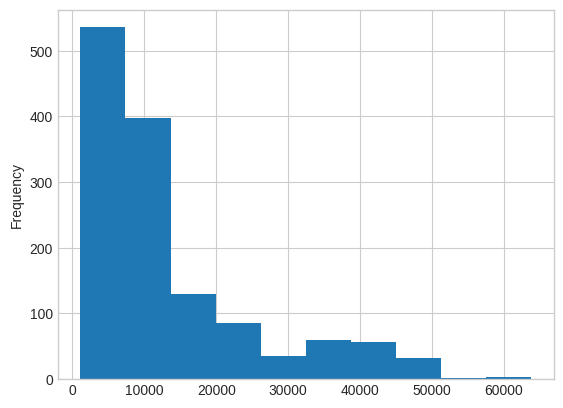

In [8]:
# TODO: Plot distribution of charges
insurance['charges'].plot.hist()

<Axes: xlabel='age', ylabel='charges'>

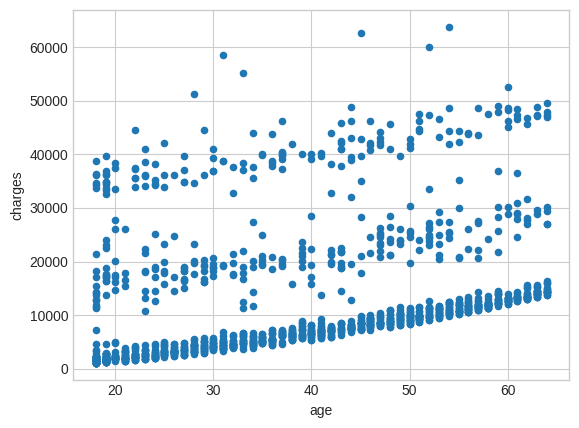

In [9]:
# TODO: Plot age vs charges
insurance.plot.scatter(x='age', y='charges')

<Axes: xlabel='bmi', ylabel='charges'>

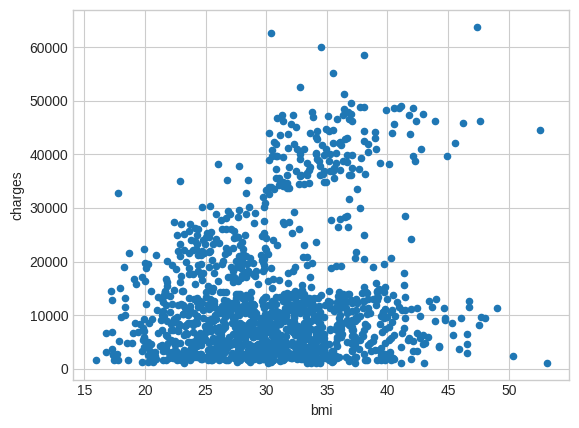

In [10]:
# TODO: Plot BMI vs charges
insurance.plot.scatter(x='bmi', y='charges')

<Axes: title={'center': 'charges'}, xlabel='smoker'>

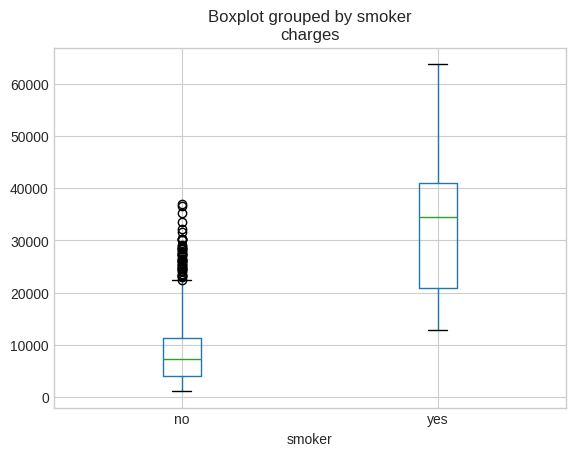

In [11]:
# TODO: Compare charges for smokers and non-smokers
# Hint: boxplot works well here
insurance.boxplot(column='charges', by='smoker')

<Axes: xlabel='region'>

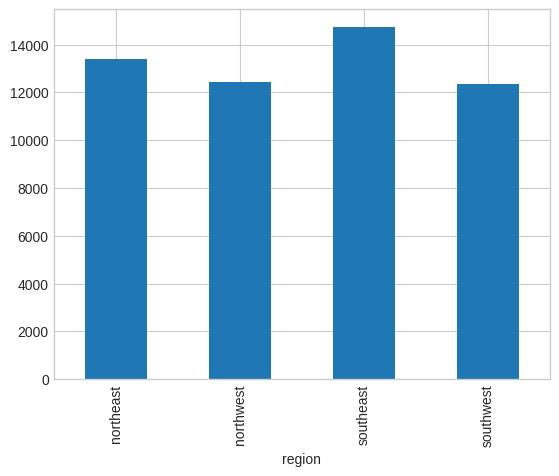

In [12]:
# TODO: Compare average charges by region
insurance.groupby('region')['charges'].mean().plot.bar()

In [16]:
insurance[['age', 'bmi','children', 'charges']].corr().style.background_gradient(cmap='viridis')

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


### EDA questions

Answer briefly:

1. Is `charges` normally distributed or skewed?
2. Does smoking seem to affect charges?
3. Does BMI show a clear relationship with charges?
4. Which numerical feature has the strongest correlation with `charges`?

###
1. Charges is skewed
2. Yes smokers pay high charges compared to non-smokers
3. I didnt see a clear pattern
4. Age shows the strongest correlation

## 4. Feature engineering

Create at least three new features.

Required:

1. `is_obese`

$$
is\_obese =
\begin{cases}
1, & BMI \ge 30 \\
0, & BMI < 30
\end{cases}
$$

2. `age_group`: group ages into buckets.

3. `smoker_bmi`: interaction between smoking and BMI.

Why interaction?

The impact of BMI may be different for smokers and non-smokers.

In [17]:
insurance_fe = insurance.copy()

# TODO: Create is_obese
insurance_fe['is_obese'] = (insurance_fe['bmi'] >= 30).astype(int)

# TODO: Create age_group
# Suggested bins: [0, 25, 35, 45, 55, 65, 100]
# Suggested labels: ["<=25", "26-35", "36-45", "46-55", "56-65", "65+"]
insurance_fe['age_group'] = pd.cut(insurance_fe['age'], bins=[0,25,35,45,55,65,100], labels=["<=25", "26-35", "36-45", "46-55", "56-65", "65+"])


# TODO: Create smoker_bmi
# Hint: convert smoker yes/no to 1/0, then multiply by bmi
insurance_fe['smoker_bmi'] = (insurance_fe['smoker'] == 'yes').astype(int) * insurance_fe['bmi']

insurance_fe.head()

,age,sex,bmi,children,smoker,region,charges,is_obese,age_group,smoker_bmi
0,19,female,27.900,0,yes,southwest,16884.92400,0,<=25,27.9
1,18,male,33.770,1,no,southeast,1725.55230,1,<=25,0.0
2,28,male,33.000,3,no,southeast,4449.46200,1,26-35,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,26-35,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,26-35,0.0


<Axes: title={'center': 'charges'}, xlabel='is_obese'>

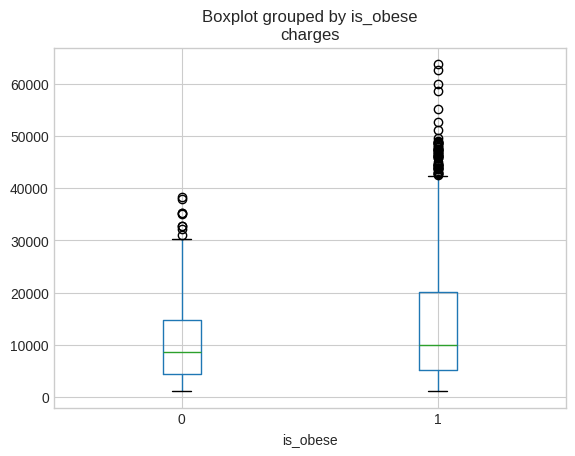

In [18]:
# TODO: Visualize charges by is_obese and smoker
insurance_fe.boxplot(column='charges', by='is_obese')

<Axes: xlabel='smoker_bmi', ylabel='charges'>

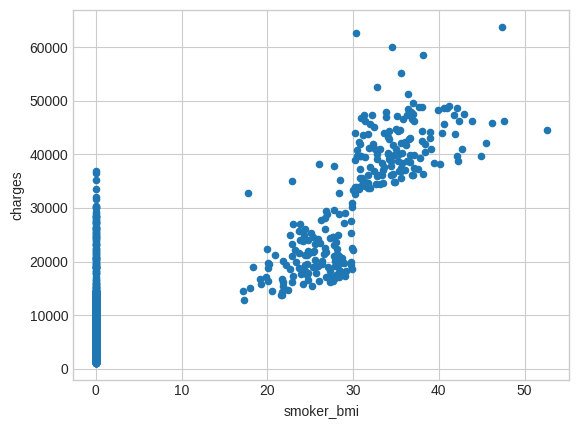

In [22]:
insurance_fe.plot.scatter(y='charges', x='smoker_bmi')

### Feature engineering questions

Answer briefly:

1. Why might `is_obese` be useful?
2. Why might `smoker_bmi` be useful?
3. Which engineered feature do you expect to help the model most?

###
1. we can see the pattern that obese people tend to have higher charges than non obese people. This was a key insight(apart from age)
2. and smokers with high bmi tend to pay higher charges too.
3. So we hadnt seen a clear pattern w.r.to bmi and charges but these engineered interaction features show us a clear pattern.


## 5. Train-test split

Use:

- 80% training data
- 20% test data
- `random_state=42`

Target:

$$
y = charges
$$

In [38]:
target = "charges"

# TODO: Create X and y
X = insurance_fe.drop(columns=target)
y = insurance_fe[target]

# TODO: Split into X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 6. Build preprocessing and model pipeline

Your pipeline should:

1. impute numerical missing values if any,
2. scale numerical features,
3. one-hot encode categorical features,
4. train Linear Regression.

In [39]:
insurance_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   age         1338 non-null   int64   
 1   sex         1338 non-null   object  
 2   bmi         1338 non-null   float64 
 3   children    1338 non-null   int64   
 4   smoker      1338 non-null   object  
 5   region      1338 non-null   object  
 6   charges     1338 non-null   float64 
 7   is_obese    1338 non-null   int64   
 8   age_group   1338 non-null   category
 9   smoker_bmi  1338 non-null   float64 
dtypes: category(1), float64(3), int64(3), object(3)
memory usage: 95.7+ KB


In [44]:
# TODO: Identify numerical and categorical columns

numeric_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

numeric_features, categorical_features

(['age', 'bmi', 'children', 'is_obese', 'smoker_bmi'],
 ['sex', 'smoker', 'region', 'age_group'])

In [45]:
# TODO: Build preprocessing pipelines

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [46]:
# TODO: Build and train Linear Regression pipeline

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi', 'children',
                                                   'is_obese', 'smoker_bmi']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'smoker', 'region',
                                                   'age_group'])])),
                ('regressor', LinearRegression())])

## 7. Evaluation metrics

Evaluate on test data using:

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
$$

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$

$$
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
$$

Also calculate adjusted R2:

$$
Adjusted\ R^2 = 1 - \frac{(1-R^2)(n-1)}{n-p-1}
$$

In [47]:
def regression_report(y_true, y_pred, n_features=None):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    report = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

    if n_features is not None:
        n = len(y_true)
        p = n_features
        adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
        report["Adjusted R2"] = adjusted_r2

    return pd.Series(report)

In [51]:
# TODO: Generate predictions on train and test data
y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

# TODO: Calculate number of transformed features
X_train_transformed = linear_model["preprocessor"].transform(X_train)
n_features = X_train_transformed.shape[1] #18
# TODO: Print train and test regression reports
print("Train regression report:")
print(regression_report(y_train, y_train_pred, n_features=n_features))

print("\n Test regression report:")
print(regression_report(y_test, y_test_pred, n_features=n_features))

Train regression report:
MAE            2.853722e+03
MSE            2.244349e+07
RMSE           4.737456e+03
R2             8.445027e-01
Adjusted R2    8.418396e-01
dtype: float64

 Test regression report:
MAE            2.760987e+03
MSE            2.083316e+07
RMSE           4.564336e+03
R2             8.658079e-01
Adjusted R2    8.561072e-01
dtype: float64


In [49]:
X_train_transformed.shape

(1070, 18)

### Evaluation questions

Answer briefly:

1. What is the model's RMSE?
2. What is the model's R2?
3. Is train performance much better than test performance?
4. Does the model appear to overfit?

###
1. 4737.4 on training set
2. 0.84 on training set
3. they seem to be similar
4. I dont see any overfit as the model performance on training and testing is more or less the same

## 8. Visualize predictions and residuals

Create:

1. Actual vs predicted plot.
2. Residuals vs predicted plot.
3. Residual distribution.

Residual:

$$
e_i = y_i - \hat{y}_i
$$

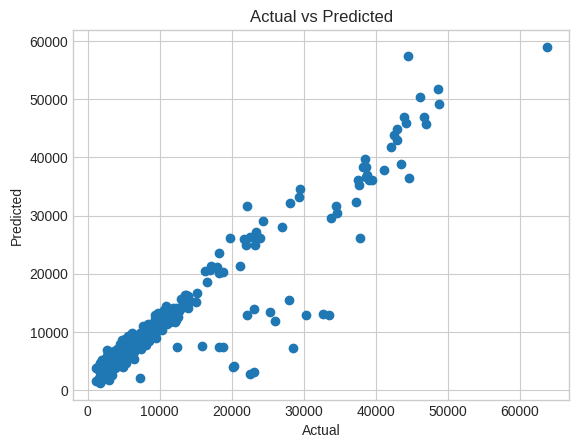

In [52]:
# TODO: Actual vs predicted plot
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

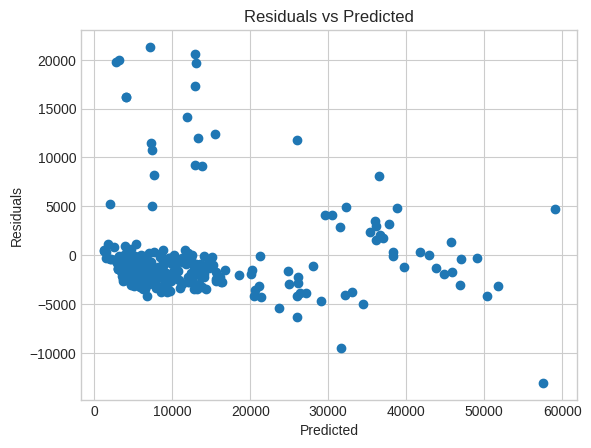

In [53]:
# TODO: Residuals vs predicted plot
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

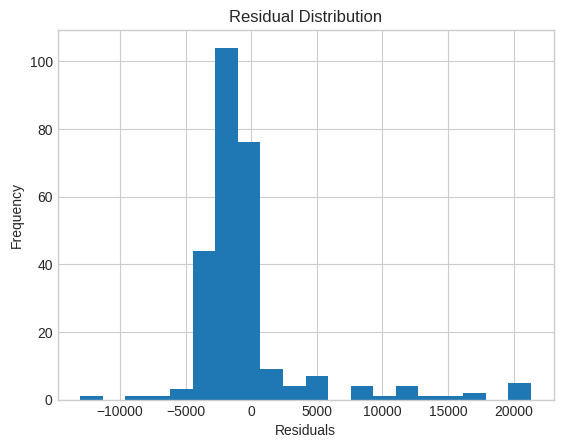

In [54]:
# TODO: Residual distribution plot
plt.hist(residuals, bins=20)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

### Residual questions

Answer briefly:

1. Are residuals centered around zero?
2. Do residuals show a pattern?
3. Does the model make larger errors for high-charge customers?

## 9. Coefficient interpretation

Extract model coefficients and identify:

- top positive coefficients,
- top negative coefficients.

Be careful:

> A coefficient shows association, not guaranteed causation.

In [55]:
# TODO: Extract transformed feature names and coefficients
feature_names = linear_model["preprocessor"].get_feature_names_out()
coefficients = linear_model["regressor"].coef_

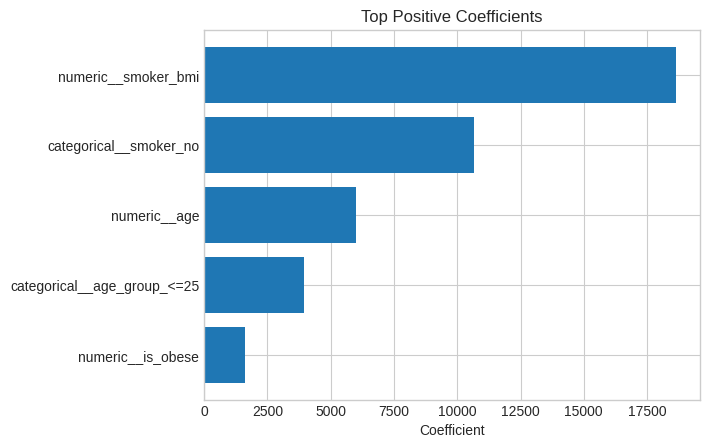

In [56]:
# TODO: Plot top positive and negative coefficients
top_positive = np.argsort(coefficients)[-5:]
top_negative = np.argsort(coefficients)[:5]

plt.barh(np.arange(5), coefficients[top_positive])
plt.yticks(np.arange(5), feature_names[top_positive])
plt.xlabel("Coefficient")
plt.title("Top Positive Coefficients")
plt.show()

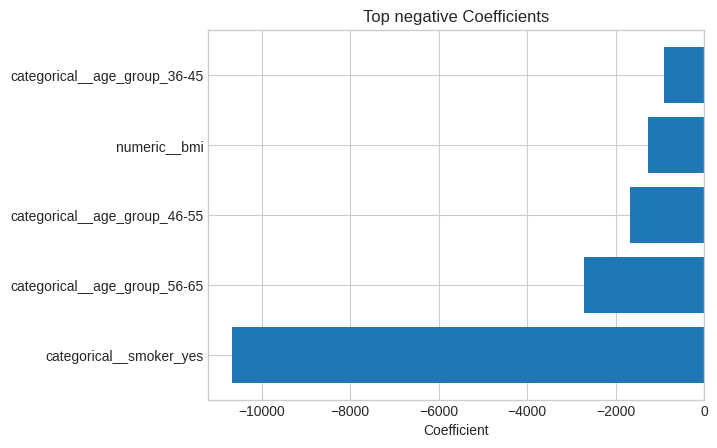

In [57]:
plt.barh(np.arange(5), coefficients[top_negative])
plt.yticks(np.arange(5), feature_names[top_negative])
plt.xlabel("Coefficient")
plt.title("Top negative Coefficients")
plt.show()

In [65]:
pd.DataFrame({'coef': coefficients, 'feature': feature_names}).sort_values(by='coef', ascending=False)

,coef,feature
4,18661.995075,numeric__smoker_bmi
7,10680.643287,categorical__smoker_no
0,6015.073093,numeric__age
17,3928.997066,categorical__age_group_<=25
3,1625.317190,numeric__is_obese
13,1377.829360,categorical__age_group_26-35
9,693.702837,categorical__region_northeast
2,688.195035,numeric__children
5,273.104900,categorical__sex_female
10,-30.672449,categorical__region_northwest


### Coefficient questions

Answer briefly:

1. Which features increase predicted charges the most?
2. Which features decrease predicted charges?
3. How strong is the impact of smoking?
4. Are the coefficient signs reasonable?

###
1. 'smoker_bmi'
2. 'smoker_yes' (counterintuitive)
3. smoking with high bmi has a higher impact as we've seen from the EDA
4. They are counter intuitive i.e. what we expect to have a positive sign have negative sign and vice versa

## 10. Multicollinearity check

Check correlation among numerical features.

High feature-feature correlation can make coefficient interpretation unstable.

Text(0.5, 1.0, 'Correlation Heatmap')

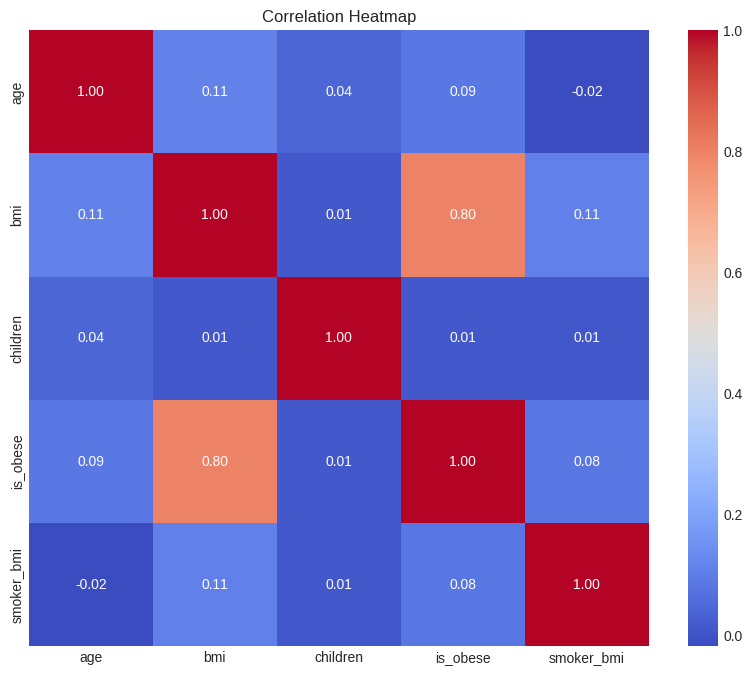

In [67]:
import seaborn as sns
# TODO: Correlation heatmap among numerical features
numeric_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
correlation_matrix = insurance_fe[numeric_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")

In [ ]:
# TODO: Show highly correlated feature pairs

### Multicollinearity questions

Answer briefly:

1. Which features are highly correlated?
2. Could this affect coefficient interpretation?
3. Would you remove any features? Why?

###
1. obesity(the categorical variable 1= yes and 0=no) and bmi are strongly correlates

3. Since is_obese variable was derived from bmi variable, they are highly correlated maybe we remove bmi variable since it showed no pattern with charges and has negative coefficient and keep is_obese variable since it has higher positive coefficient and helps us understand the pattern between it and the charges

## 11. Compare with Ridge Regression

Ridge adds a penalty for large coefficients:

$$
\text{Ridge: } \min(MSE + \lambda\sum_j \beta_j^2)
$$

Train a Ridge model and compare it with Linear Regression.

In [68]:
# TODO: Build and train Ridge regression pipeline

ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi', 'children',
                                                   'is_obese', 'smoker_bmi']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'smoker', 'region',
                                                   'age_group'])])),
                ('regressor', Ridge())])

In [69]:
# TODO: Compare Linear Regression and Ridge using MAE, RMSE, R2, adjusted R2
y_pred_ridge = ridge_model.predict(X_test)

Ridge_report = regression_report(y_test, y_pred_ridge, n_features=n_features)
Linear_report = regression_report(y_test, y_test_pred, n_features=n_features)

print("Ridge Regression Report:")
print(Ridge_report)

print("\nLinear Regression Report:")
print(Linear_report)



Ridge Regression Report:
MAE            2.761835e+03
MSE            2.066577e+07
RMSE           4.545962e+03
R2             8.668860e-01
Adjusted R2    8.572633e-01
dtype: float64

Linear Regression Report:
MAE            2.760987e+03
MSE            2.083316e+07
RMSE           4.564336e+03
R2             8.658079e-01
Adjusted R2    8.561072e-01
dtype: float64


In [70]:
ridge_feature_names = ridge_model["preprocessor"].get_feature_names_out()
ridge_coefficients = ridge_model["regressor"].coef_

In [71]:
pd.DataFrame({'feature': ridge_feature_names, 'coef': ridge_coefficients}).sort_values(by='coef', ascending=False)

,feature,coef
4,numeric__smoker_bmi,17669.719006
7,categorical__smoker_no,9457.107534
0,numeric__age,5628.179244
17,categorical__age_group_<=25,3384.843409
3,numeric__is_obese,1617.869606
13,categorical__age_group_26-35,1084.905179
2,numeric__children,686.884481
9,categorical__region_northeast,673.949325
5,categorical__sex_female,261.131450
10,categorical__region_northwest,-24.468026


### Ridge questions

Answer briefly:

1. Did Ridge improve test performance?
2. Did Ridge reduce coefficient magnitudes?
3. Why might regularization help?

####
1. Ridge improved the upon the linear model by 16%
2. Ridge reduced the coeffecient magnitudes
3. Ridge Regression by adding L2 penalty and shrinking coeffiecents improved the model

## 12. Stretch goals

Try any two:

1. Compare with Lasso Regression.
2. Apply log transform to `charges` and compare performance.
3. Train separate models for smokers and non-smokers.
4. Add polynomial features for `age` or `bmi`.
5. Remove highly correlated features and retrain.

In [ ]:
# Optional stretch work here

## Final written summary

Write 5-8 bullet points:

1. What were the most important findings from EDA?
2. Which model performed better?
3. Which features were most influential?
4. Where did the model make larger mistakes?
5. Is linear regression sufficient for this dataset?
6. What would you try next to improve the model?

###
1. The target variable was skewed & there wasnt a clear pattern between the predictors and target except that smokers were charged more than non-smokers.However after we did feature engineering the new variables, smoker_bmi and is_obese showed a clear pattern

2. Ridge model is 16% better than the linear model( R2 score of Ridge was 0.87 and 0.86 for linear model)

3. numeric variable smoker_bmi had the most influence in the positive direction and counter intuitively categorical variable smoker_yes had the most influence in the negative direction

4. the model under-predicted a few observations whose charges variables was in the range 2000 - 3500.

5. the linear model (& as well as the ridge model) performed very well on the test dataset, however 0.87 R2 is subjective, we must consult the SME whether they are happy with the model's prediction or whether they want even more powerful model.

6. Transform the data by taking log and then fit a regression model. Or try different algorithm all together maybe Decision Trees or Random Forest (or since the model makes errors in the range 2000 - 3500, we can try boosting algorithms like XGBoost or ADAboost to overcome this issue if the foible of linear model is too critical)